In [5]:
%reset -f -s


import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from PIL import Image, ImageDraw, ImageFont
from pycocotools.coco import COCO
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from utils.takehome import DWDataset, CLASS_NAMES, display_random_deepweed_images


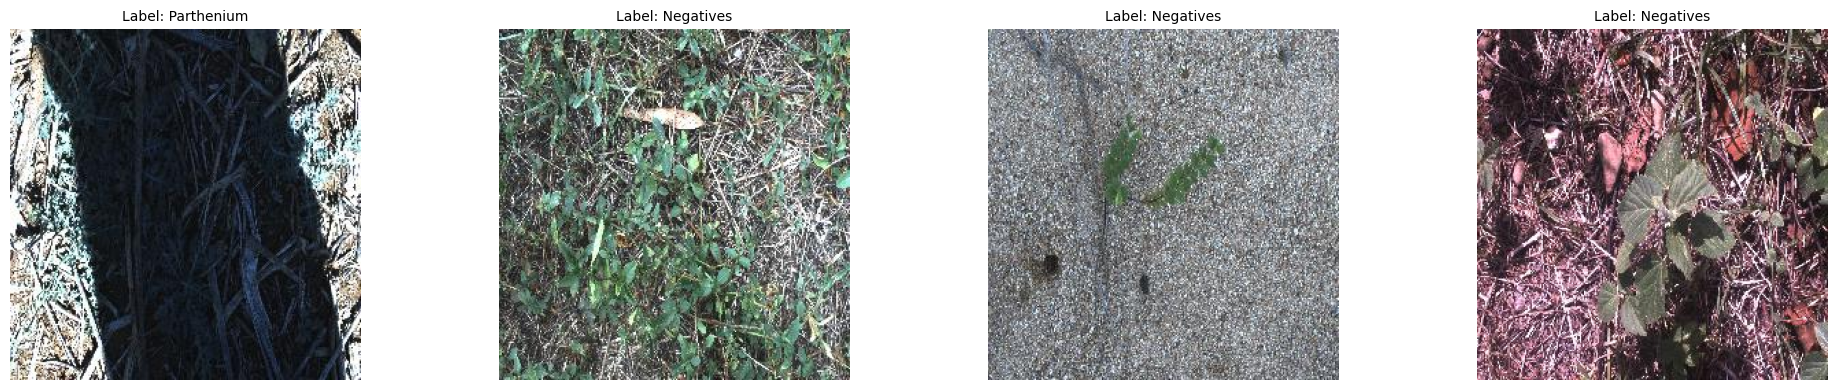

In [6]:

# Example usage:
dataset = DWDataset(Path("deepweeds"), "test_subset0")
display_random_deepweed_images(dataset, num_images=4)

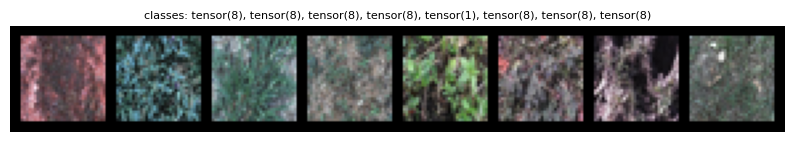

In [11]:
def imshow(inp, title=None):
    plt.figure(figsize=(10, 5))
    inp = inp.numpy().transpose((1, 2, 0))
    
    plt.imshow(inp)
    if title is not None:
        plt.title(title, fontsize=8)
    plt.axis('off')


data_transforms = transforms.Compose([
    transforms.Resize(32, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(32),
    transforms.ToTensor(), 
])

dataloader = DataLoader(
    DWDataset(Path("deepweeds"), "test_subset0", transforms=data_transforms), batch_size=8, shuffle=True, num_workers=2
)
inputs, classes = next(iter(dataloader))
imshow(torchvision.utils.make_grid(inputs, padding=4), title=f"classes: {', '.join([str(x) for x in classes])}")

# Experiments
## Logistic regression on frozen encoder output (h) vs. first layer of projector (z1) over replicates and batch sizes


In [21]:
%reset -f -s
import numpy as np
import pandas as pd
import seaborn as sns
from utils.takehome import CLASS_NAMES
sns.set_theme()
df = pd.read_csv("results/results.csv")
df.loc[lambda x: (x.replicate==0) & (x.split=="val")].head()

,epoch,split,loss,accuracy,feature,batch_size,replicate
7,5,val,1.092657,0.607240,H,16,0
13,10,val,1.040822,0.628359,H,16,0
19,15,val,1.022484,0.639774,H,16,0
25,20,val,1.007701,0.649192,H,16,0
31,25,val,0.969808,0.649192,H,16,0


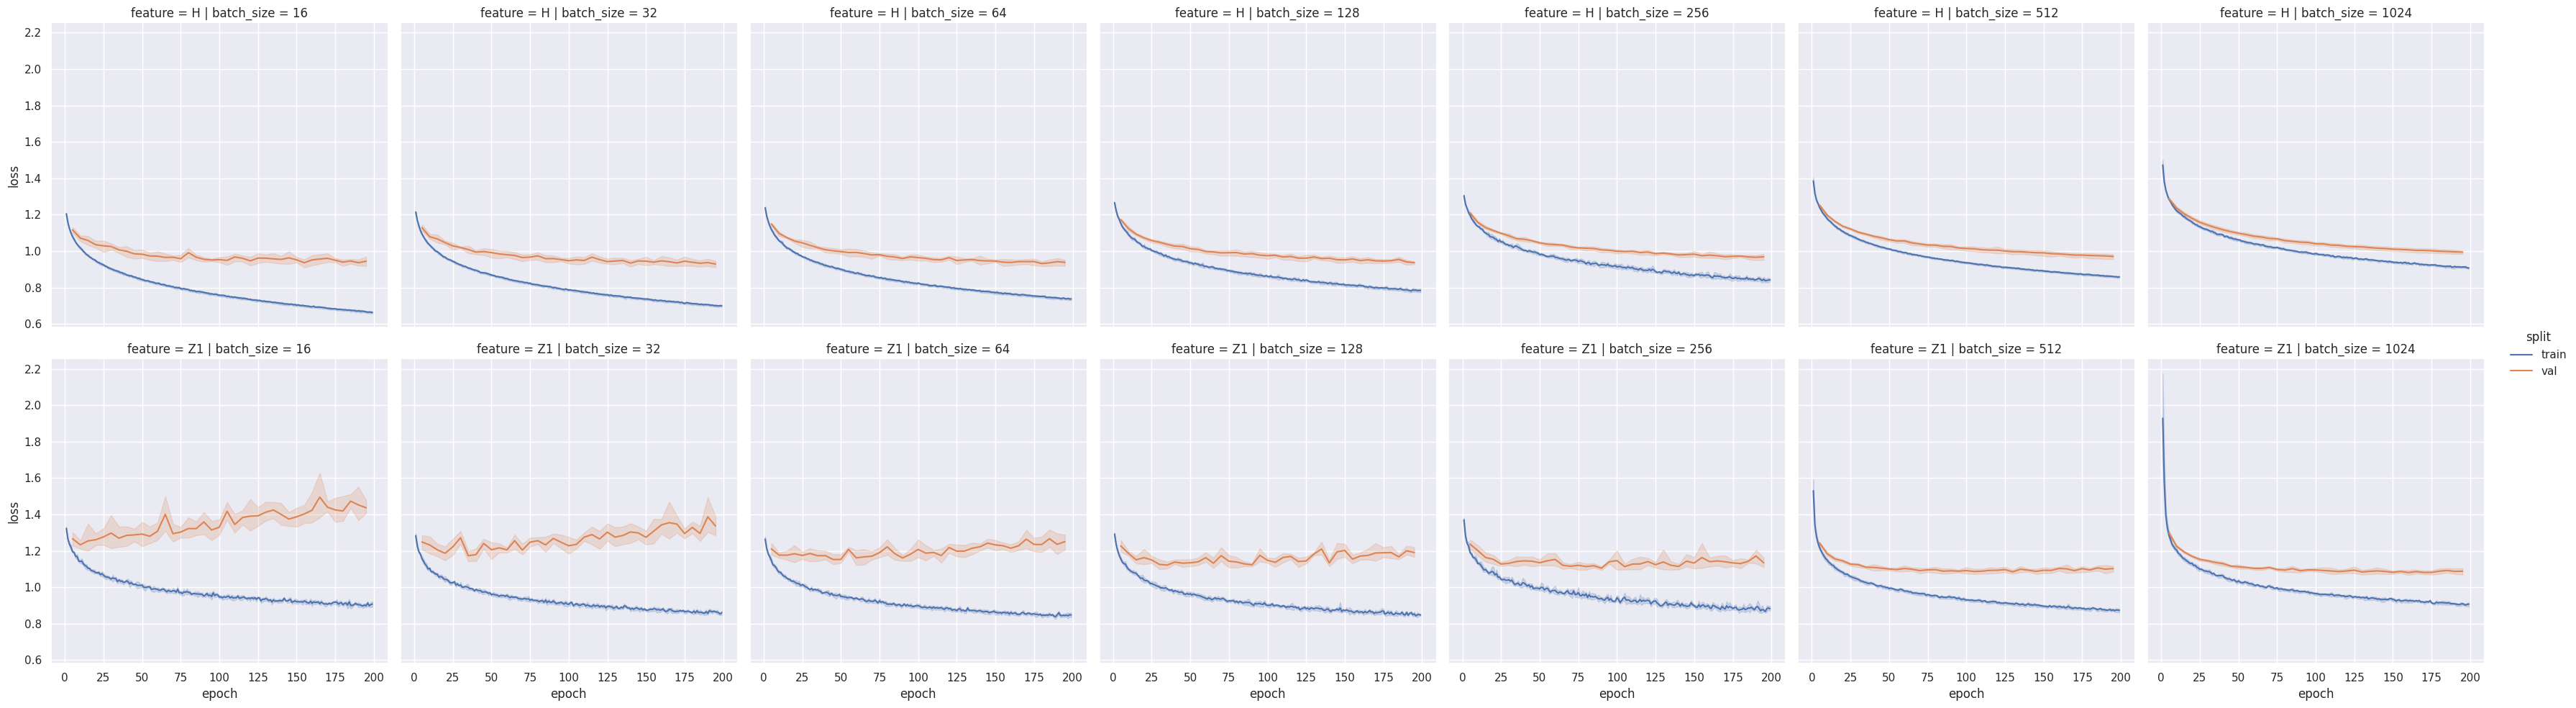

In [22]:
sns.relplot(
    data=df.loc[lambda x: (x.epoch > 0) & (x.split != "test")], 
    y="loss", x="epoch", kind="line", hue="split", col="batch_size", row="feature"
)

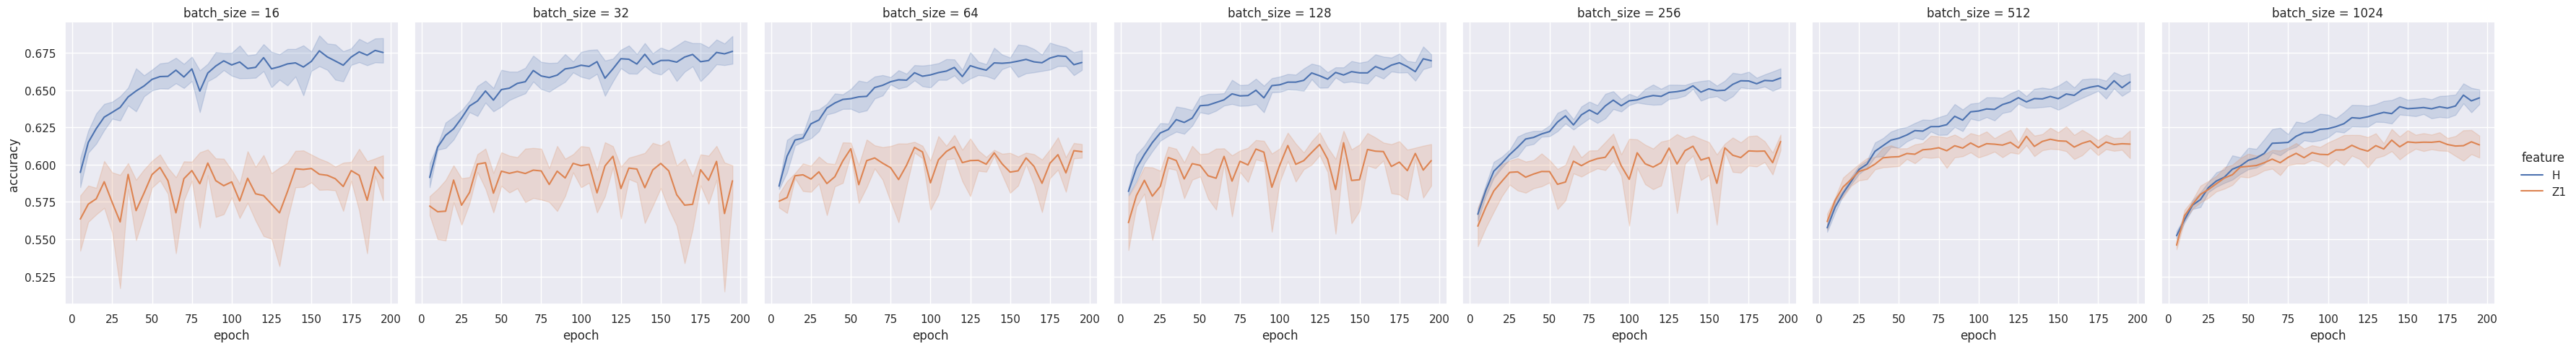

In [23]:
sns.relplot(
    data=df.loc[lambda x: (x.epoch > 0) & (x.split == "val")], 
    y="accuracy", x="epoch", kind="line", hue="feature", col="batch_size"
)

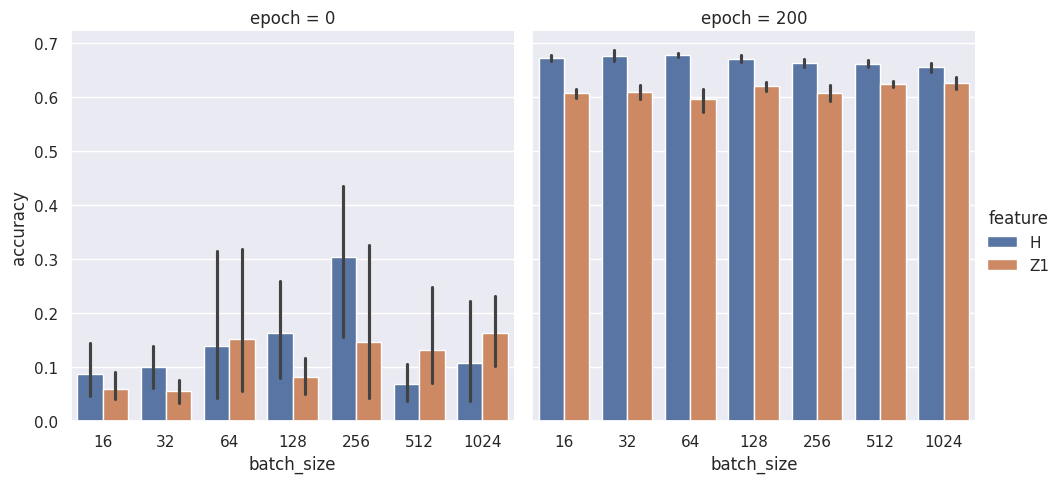

In [24]:
sns.catplot(
    data=df.loc[lambda x: (x.split == "test")], 
    y="accuracy", x="batch_size", hue="feature", kind="bar", col="epoch"
)

In [25]:
repl = 0
y_tilde_h = np.load(f"results/H_bs32_repl{repl}.npy") # Nxd
N, d = y_tilde_h.shape
y = pd.read_csv(f"deepweeds/labels/test_subset{repl}.csv").Label._values
np.allclose(y_tilde_h.sum(axis=1), 1), y_tilde_h.shape, y.shape 

(True, (3507, 9), (3507,))

In [26]:
sdf = pd.DataFrame({"py": y_tilde_h[np.arange(N), y], "y": y}).assign(labels=lambda x: [CLASS_NAMES[i] for i in x.y])
sdf.head()

,py,y,labels
0,0.000938,0,Chinee Apple
1,0.001664,0,Chinee Apple
2,0.149267,0,Chinee Apple
3,0.005386,0,Chinee Apple
4,0.001656,0,Chinee Apple


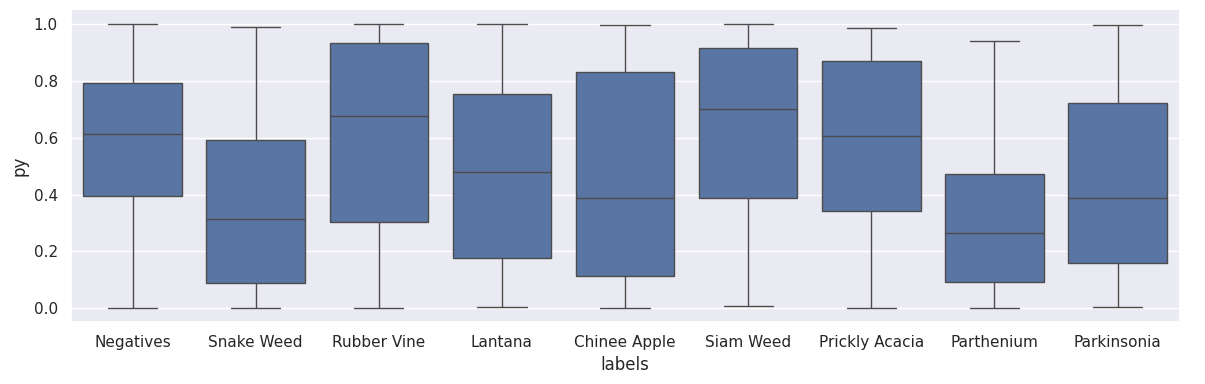

In [40]:
sns.catplot(sdf, x="labels", y="py", kind="box", aspect=3, height=4)

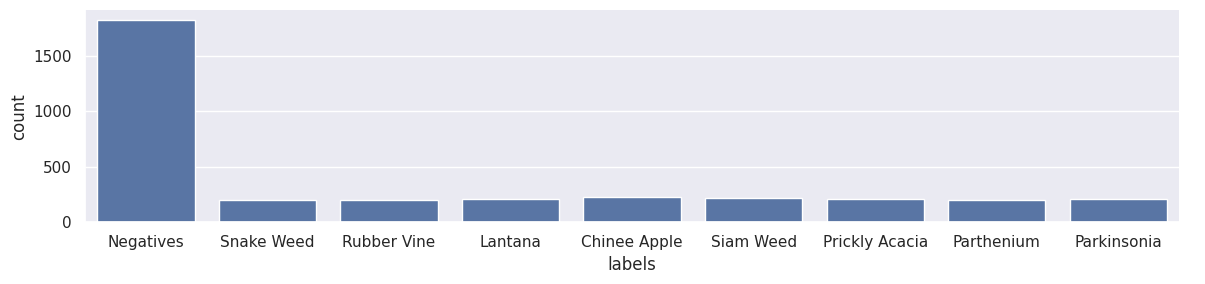

In [37]:
sns.catplot(sdf, x="labels", kind="count", aspect=4, height=3)